In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

ModuleNotFoundError: No module named 'streamlit'

In [ ]:
st.set_page_config(
    page_title="Stock Price Prediction",
    page_icon="📈",
    layout="wide"

In [ ]:
st.markdown("""
<style>

.main {
    background-color: #0E1117;
    color: white;
}

h1, h2, h3 {
    color: #00BFFF;
}

.stButton>button {
    background-color: #00BFFF;
    color: white;
    border-radius: 10px;
    height: 50px;
    width: 100%;
    font-size: 18px;
}

.stNumberInput input {
    background-color: #1E1E1E;
    color: white;
}

</style>
""", unsafe_allow_html=True)

In [ ]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

data = pd.read_csv(
    r"C:\Users\Cherry\OneDrive\Documents\Downloads\archive.zip",
    compression='zip'
)

data

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900
5,2018-02-12,252.139999,259.149994,249.000000,257.950012,257.950012,8534900
6,2018-02-13,257.290009,261.410004,254.699997,258.269989,258.269989,6855200
7,2018-02-14,260.470001,269.880005,260.329987,266.000000,266.000000,10972000
8,2018-02-15,270.029999,280.500000,267.630005,280.269989,280.269989,10759700
9,2018-02-16,278.730011,281.959991,275.690002,278.519989,278.519989,8312400


In [ ]:
print("FIRST 5 ROWS OF DATASET")
print(data.head())

print("\nDATASET INFORMATION")
print(data.info())

print("\nCOLUMN NAMES")
print(data.columns)


FIRST 5 ROWS OF DATASET
         Date        Open        High         Low       Close   Adj Close  \
0  2018-02-05  262.000000  267.899994  250.029999  254.259995  254.259995   
1  2018-02-06  247.699997  266.700012  245.000000  265.720001  265.720001   
2  2018-02-07  266.579987  272.450012  264.329987  264.559998  264.559998   
3  2018-02-08  267.079987  267.619995  250.000000  250.100006  250.100006   
4  2018-02-09  253.850006  255.800003  236.110001  249.470001  249.470001   

     Volume  
0  11896100  
1  12595800  
2   8981500  
3   9306700  
4  16906900  

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1009 non-null   object 
 1   Open       1009 non-null   float64
 2   High       1009 non-null   float64
 3   Low        1009 non-null   float64
 4   Close      1009 non-null   float64
 5   Adj Close  1009 n

In [ ]:
print("\nMISSING VALUES")
print(data.isnull().sum())

# Remove missing values
data = data.dropna()



MISSING VALUES
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


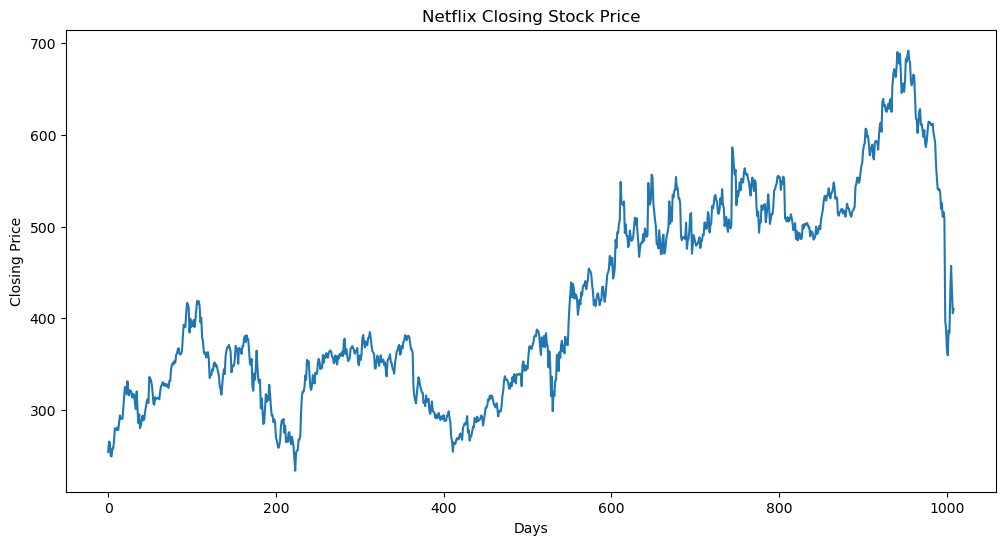

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(data['Close'])

plt.title('Netflix Closing Stock Price')

plt.xlabel('Days')

plt.ylabel('Closing Price')

plt.show()

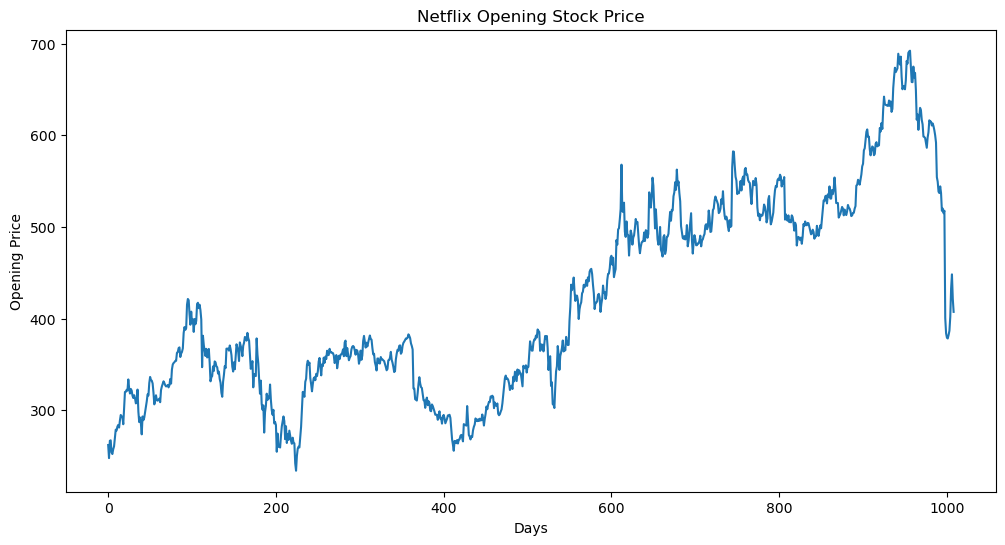

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(data['Open'])

plt.title('Netflix Opening Stock Price')

plt.xlabel('Days')

plt.ylabel('Opening Price')

plt.show()


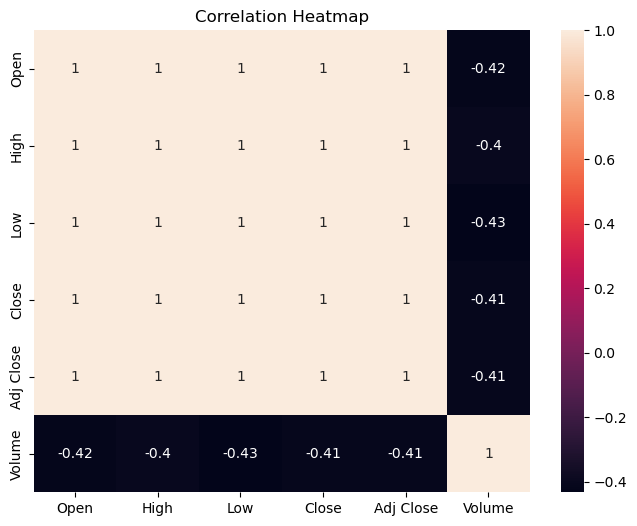

In [ ]:
numeric_data = data.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))

sns.heatmap(numeric_data.corr(), annot=True)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
X = data[['Open', 'High', 'Low', 'Volume']]

y = data['Close']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
forest_model = RandomForestRegressor(

    n_estimators=100,
    random_state=42

)

forest_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
linear_predictions = linear_model.predict(X_test)

In [ ]:
forest_predictions = forest_model.predict(X_test)

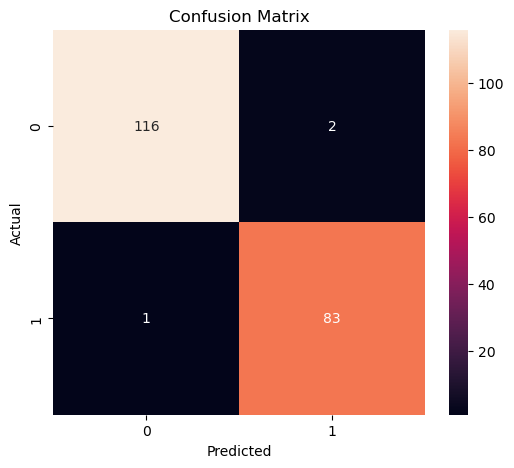

In [ ]:
y_test_class = (y_test > y_test.mean()).astype(int)

forest_pred_class = (forest_predictions > y_test.mean()).astype(int)

# Create confusion matrix

cm = confusion_matrix(y_test_class, forest_pred_class)

# Plot confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
linear_mse = mean_squared_error(y_test, linear_predictions)

linear_r2 = r2_score(y_test, linear_predictions)

linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_accuracy = linear_r2 * 100

print("LINEAR REGRESSION RESULTS")

print("Mean Squared Error:", linear_mse)

print("Mean Absolute Error:", linear_mae)

print("Accuracy:", linear_accuracy, "%")

LINEAR REGRESSION RESULTS
Mean Squared Error: 15.976946096061795
Mean Absolute Error: 2.857186533151788
Accuracy: 99.86297713881959 %


In [ ]:
forest_mse = mean_squared_error(y_test, forest_predictions)

forest_r2 = r2_score(y_test, forest_predictions)

forest_mae = mean_absolute_error(y_test, forest_predictions)

forest_accuracy = forest_r2 * 100

print("RANDOM FOREST RESULTS")

print("Mean Squared Error:", forest_mse)

print("Mean Absolute Error:", forest_mae)

print("Accuracy:", forest_accuracy, "%")

RANDOM FOREST RESULTS
Mean Squared Error: 27.71261922965426
Mean Absolute Error: 3.7096233236633944
Accuracy: 99.76232864811463 %


In [ ]:
comparison = pd.DataFrame({

    'Actual Price': y_test.values,

    'Linear Prediction': linear_predictions,

    'Random Forest Prediction': forest_predictions

})

print(comparison.head(10))

   Actual Price  Linear Prediction  Random Forest Prediction
0    509.640015         508.503210                507.383196
1    494.730011         492.622129                492.626902
2    500.859985         506.904498                510.107499
3    380.070007         380.941828                383.827598
4    315.100006         319.219895                321.035300
5    476.260010         480.187156                481.113699
6    495.989990         493.191910                490.384795
7    298.839996         319.768368                318.094401
8    359.309998         360.885139                361.393598
9    328.190002         328.202743                329.362300


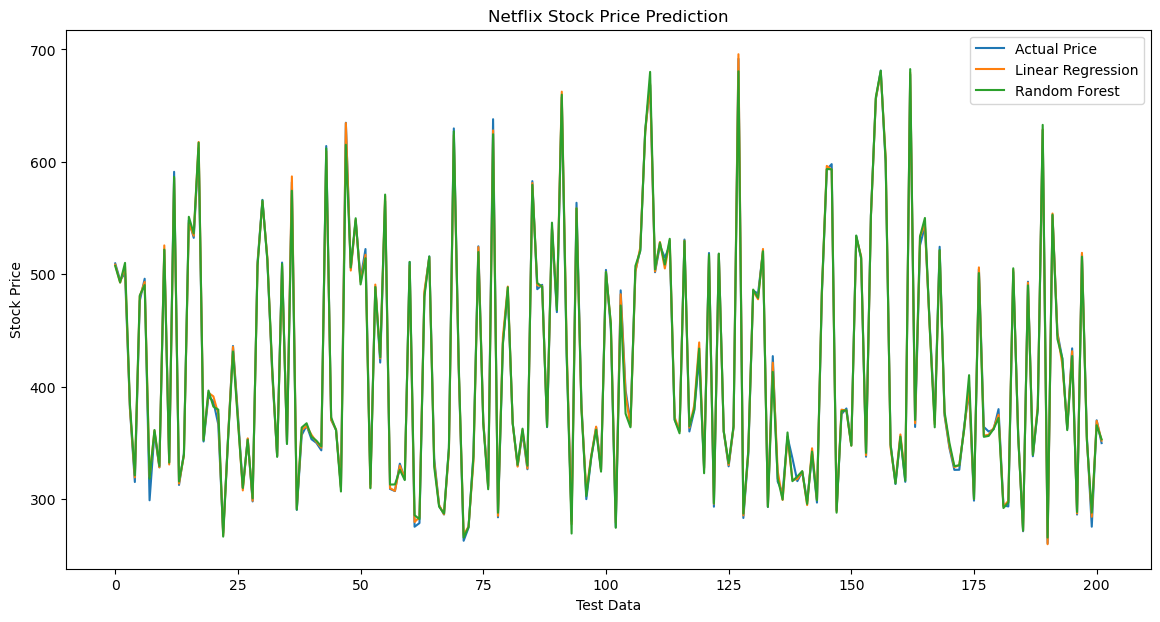

In [ ]:
plt.figure(figsize=(14,7))

plt.plot(y_test.values, label='Actual Price')

plt.plot(linear_predictions, label='Linear Regression')

plt.plot(forest_predictions, label='Random Forest')

plt.legend()

plt.title('Netflix Stock Price Prediction')

plt.xlabel('Test Data')

plt.ylabel('Stock Price')

plt.show()

In [ ]:
sample_data = pd.DataFrame({

    'Open': [500],

    'High': [510],

    'Low': [495],

    'Volume': [3000000]

})

In [ ]:
linear_new_prediction = linear_model.predict(sample_data)

print(linear_new_prediction)

[503.99851057]


In [ ]:
forest_new_prediction = forest_model.predict(sample_data)

print(forest_new_prediction)

[503.50349741]


In [ ]:
import joblib

joblib.dump(forest_model, 'netflix_stock_model.pkl')

print("MODEL SAVED SUCCESSFULLY")

MODEL SAVED SUCCESSFULLY
